<a href="https://colab.research.google.com/github/rpaivadias69/MALE_Abgaben_PVA-s_Nachbearbeitungen/blob/PVA4/MALE_PVA4_Nachbereitungsaufgaben_RaulPaivaDias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 8: Dimensionality Reduction

Q1: What are the main motivations for reducing a dataset's dimensionality? What are the main drawbacks?

A1: Reducing the number of features can make datasets easier to work with. Models usually train faster, require less memory, and sometimes even achieve better results because irrelevant or redundant information is removed. It is also useful when visualizing data that originally has many dimensions.

The downside is that some information may be lost during the process. If important details are removed, the model's performance can decrease and the transformed features are often more difficult to interpret.


Q2: What is the curse of dimensionality?

A2: As the number of dimensions increases, the amount of data needed to represent the problem grows rapidly. Data points become more spread out, making it harder for algorithms to find meaningful patterns. Many machine learning methods therefore become less effective when dealing with very high-dimensional data.

Q3: Once a dataset's dimensionality has been reduced, is it possible to reverse the operation? If so, how? If not, why?

A3: In most cases, not perfectly. Dimensionality reduction often removes part of the original information, and once that information is discarded it cannot be recovered exactly. Some techniques, such as PCA, allow an approximate reconstruction of the original data, but the result will generally not be identical to the starting dataset.

Q4: Can PCA be used to reduce the dimensionality of a highly nonlinear dataset?

A4: Not very effectively. PCA is a linear dimensionality reduction technique and works best when the data lies close to a linear subspace. For highly nonlinear datasets, PCA may fail to capture the underlying structure. In such cases, nonlinear techniques such as Kernel PCA, t-SNE, or UMAP are generally more appropriate.

Q5: Suppose you perform PCA on a 1,000-dimensional dataset, setting the explained variance ratio to 95%. How many dimensions will the resulting dataset have?

A5: There is not enough information to determine the exact number of resulting dimensions. The number of principal components required to preserve 95% of the variance depends on the structure of the dataset. It could be a small number if many features are highly correlated, or much larger if the variance is spread across many dimensions.

Q6: In what cases would you use regular PCA, incremental PCA, randomized PCA, or random projection?

A6: Regular PCA: When the dataset fits comfortably into memory and an exact solution is desired.

Incremental PCA: When the dataset is too large to fit into memory and must be processed in batches.

Randomized PCA: When the dataset is large and a faster approximate solution is acceptable.

Random Projection: When very high-dimensional data must be reduced quickly and preserving exact variance is less important than computational efficiency.

Q7: How can you evaluate the performance of a dimensionality reduction algorithm on your dataset?

A7: One way is to check how much information has been preserved after the reduction. Another possibility is to compare the performance of a machine learning model before and after dimensionality reduction. If the model performs similarly while using fewer features, the reduction can be considered successful.

Q8: Does it make any sense to chain two different dimensionality reduction algorithms?

A8: Yes, in some situations it can be beneficial. For example, PCA can first reduce the number of dimensions to a manageable level, after which another technique such as t-SNE can be used for visualization. This often reduces computation time while still preserving important patterns in the data.


In [8]:
####### Exercise 9 ##########

# Imports
## %pip install tensorflow --> had to install TensorFlow... I connected Google Colab to Local Runtime since last time computing power wasn't enough, but it would always time out using openml.... so I changed the import way to tensorflow
## I didn't know TensorFlow before, ChatGPT helped me with the TimeOut Issue while fetching nmist
import time
import numpy as np

from tensorflow.keras.datasets import mnist

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# Load and split MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten 28x28 images into 784 features
X_train = X_train.reshape(60_000, 784)
X_test = X_test.reshape(10_000, 784)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)



Training set: (60000, 784)
Test set: (10000, 784)


In [9]:
# Random Forest without PCA
rnd_clf = RandomForestClassifier(random_state=42)

start_time = time.time()
rnd_clf.fit(X_train, y_train)
rnd_train_time = time.time() - start_time

y_pred = rnd_clf.predict(X_test)
rnd_accuracy = accuracy_score(y_test, y_pred)

print(f"Training time without PCA: {rnd_train_time:.2f} seconds")
print(f"Accuracy without PCA: {rnd_accuracy:.4f}")


Training time without PCA: 47.13 seconds
Accuracy without PCA: 0.9705


In [10]:
# PCA with 95% explained variance
pca = PCA(n_components=0.95, random_state=42)

start_time = time.time()
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)
pca_time = time.time() - start_time

print(f"PCA time: {pca_time:.2f} seconds")
print(f"Original dimensions: {X_train.shape[1]}")
print(f"Reduced dimensions: {X_train_reduced.shape[1]}")


PCA time: 0.92 seconds
Original dimensions: 784
Reduced dimensions: 154


In [11]:
# Random Forest with PCA
rnd_clf_pca = RandomForestClassifier(random_state=42)

start_time = time.time()
rnd_clf_pca.fit(X_train_reduced, y_train)
rnd_pca_train_time = time.time() - start_time

y_pred_pca = rnd_clf_pca.predict(X_test_reduced)
rnd_pca_accuracy = accuracy_score(y_test, y_pred_pca)

print(f"Training time with PCA: {rnd_pca_train_time:.2f} seconds")
print(f"Accuracy with PCA: {rnd_pca_accuracy:.4f}")


Training time with PCA: 153.79 seconds
Accuracy with PCA: 0.9488


In [12]:
# Comparison for Random Forest
print("Random Forest comparison")
print("------------------------")
print(f"Without PCA: {rnd_train_time:.2f}s, accuracy = {rnd_accuracy:.4f}")
print(f"With PCA:    {rnd_pca_train_time:.2f}s, accuracy = {rnd_pca_accuracy:.4f}")


Random Forest comparison
------------------------
Without PCA: 47.13s, accuracy = 0.9705
With PCA:    153.79s, accuracy = 0.9488


In [13]:
# SGDClassifier without PCA
sgd_clf = SGDClassifier(random_state=42)

start_time = time.time()
sgd_clf.fit(X_train, y_train)
sgd_train_time = time.time() - start_time

y_pred_sgd = sgd_clf.predict(X_test)
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)

print(f"SGD training time without PCA: {sgd_train_time:.2f} seconds")
print(f"SGD accuracy without PCA: {sgd_accuracy:.4f}")


SGD training time without PCA: 182.21 seconds
SGD accuracy without PCA: 0.8740


In [14]:
# SGDClassifier with PCA
sgd_clf_pca = SGDClassifier(random_state=42)

start_time = time.time()
sgd_clf_pca.fit(X_train_reduced, y_train)
sgd_pca_train_time = time.time() - start_time

y_pred_sgd_pca = sgd_clf_pca.predict(X_test_reduced)
sgd_pca_accuracy = accuracy_score(y_test, y_pred_sgd_pca)

print(f"SGD training time with PCA: {sgd_pca_train_time:.2f} seconds")
print(f"SGD accuracy with PCA: {sgd_pca_accuracy:.4f}")


SGD training time with PCA: 36.60 seconds
SGD accuracy with PCA: 0.8959


In [15]:
# Final Comparison
print("Final comparison")
print("----------------")
print(f"Random Forest without PCA: {rnd_train_time:.2f}s, accuracy = {rnd_accuracy:.4f}")
print(f"Random Forest with PCA:    {rnd_pca_train_time:.2f}s, accuracy = {rnd_pca_accuracy:.4f}")
print()
print(f"SGD without PCA:           {sgd_train_time:.2f}s, accuracy = {sgd_accuracy:.4f}")
print(f"SGD with PCA:              {sgd_pca_train_time:.2f}s, accuracy = {sgd_pca_accuracy:.4f}")


Final comparison
----------------
Random Forest without PCA: 47.13s, accuracy = 0.9705
Random Forest with PCA:    153.79s, accuracy = 0.9488

SGD without PCA:           182.21s, accuracy = 0.8740
SGD with PCA:              36.60s, accuracy = 0.8959


In [ ]:
## For Random Forest, PCA did not help. Training became slower, from 47.13s to 153.79s, and accuracy decreased from 0.9705 to 0.9488.

## For SGDClassifier, PCA helped clearly. Training time decreased from 182.21s to 36.60s, and accuracy even improved from 0.8740 to 0.8959.

In [16]:
###### Exercise 10 ########

# Prepare first 5,000 MNIST images

from sklearn.manifold import TSNE, LocallyLinearEmbedding, MDS
import matplotlib.pyplot as plt

X_sample = X_train[:5_000]
y_sample = y_train[:5_000]

X_sample.shape, y_sample.shape

((5000, 784), (5000,))

In [17]:
# t-SNE to 2D

tsne = TSNE(n_components=2, random_state=42, init="random", learning_rate="auto")

start_time = time.time()
X_tsne = tsne.fit_transform(X_sample)
tsne_time = time.time() - start_time

print(f"t-SNE time: {tsne_time:.2f} seconds")
print(X_tsne.shape)

t-SNE time: 25.30 seconds
(5000, 2)


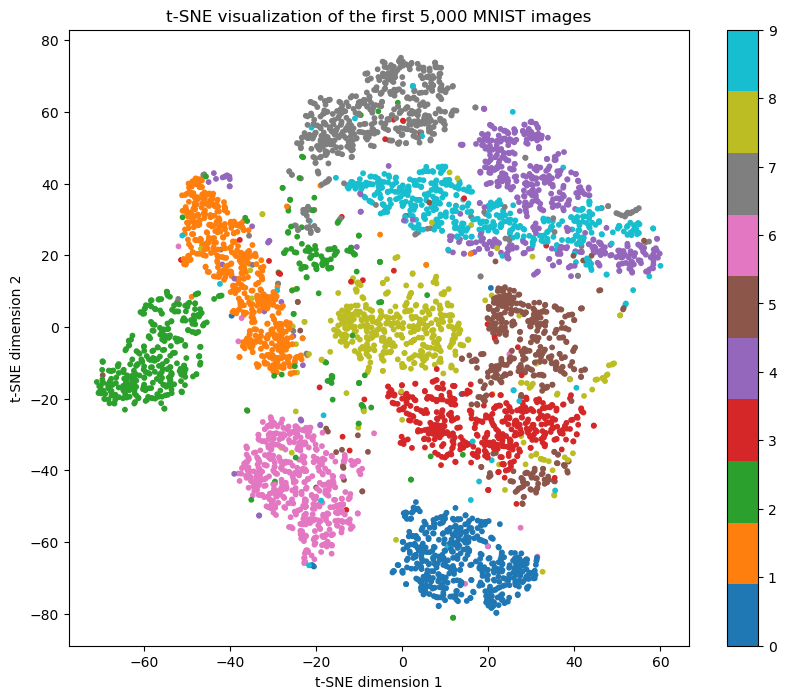

In [18]:
# Plot t-SNE result

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_sample,
    cmap="tab10",
    s=10
)

plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE visualization of the first 5,000 MNIST images")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.show()


In [19]:
# PCA comparison

pca_2d = PCA(n_components=2, random_state=42)

start_time = time.time()
X_pca_2d = pca_2d.fit_transform(X_sample)
pca_2d_time = time.time() - start_time

print(f"PCA time: {pca_2d_time:.2f} seconds")

PCA time: 0.11 seconds


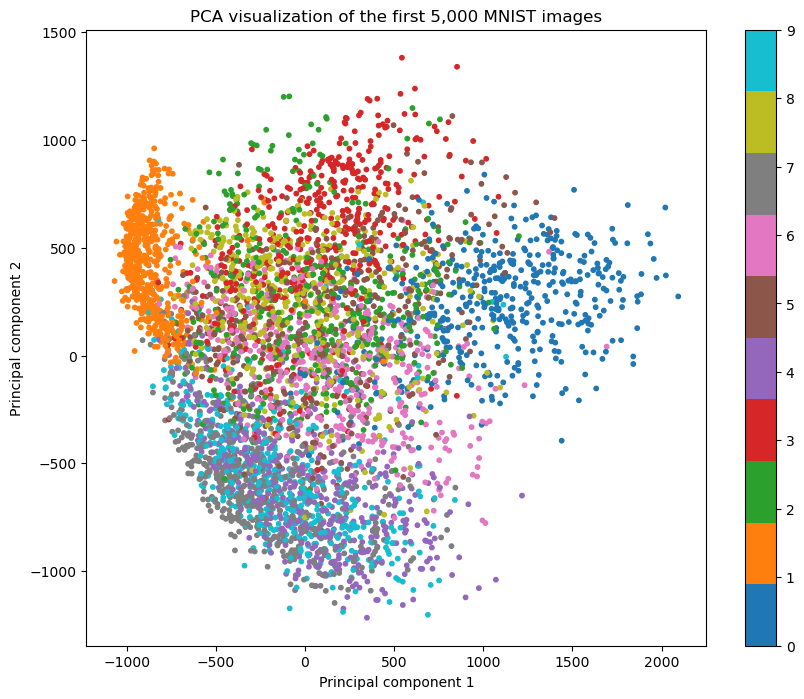

In [20]:
#Plot$

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y_sample,
    cmap="tab10",
    s=10
)

plt.colorbar(scatter, ticks=range(10))
plt.title("PCA visualization of the first 5,000 MNIST images")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.show()

In [21]:
# LLE comparison

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)

start_time = time.time()
X_lle = lle.fit_transform(X_sample)
lle_time = time.time() - start_time

print(f"LLE time: {lle_time:.2f} seconds")

LLE time: 5.58 seconds


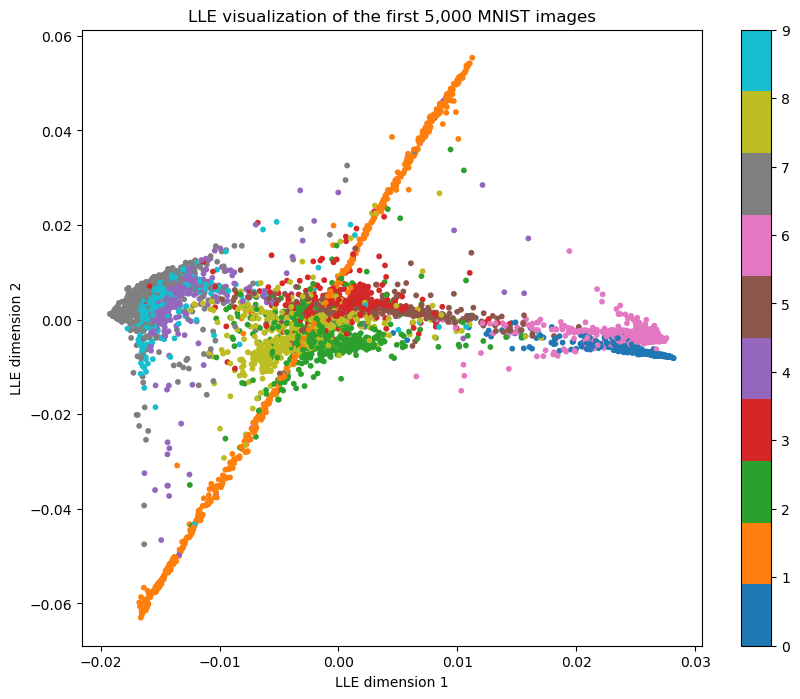

In [22]:
# Plot

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_lle[:, 0],
    X_lle[:, 1],
    c=y_sample,
    cmap="tab10",
    s=10
)

plt.colorbar(scatter, ticks=range(10))
plt.title("LLE visualization of the first 5,000 MNIST images")
plt.xlabel("LLE dimension 1")
plt.ylabel("LLE dimension 2")
plt.show()

In [ ]:
## PCA was the fastest dimensionality reduction method, but the resulting visualization showed significant overlap between digit classes.
## LLE produced a better separation of the classes while still being reasonably fast.
## The t-SNE visualization provided the clearest clustering of digits, making it the most useful method for visualizing the MNIST dataset.
## However, it required significantly more computation time than PCA and LLE.